# 🦜 BirdCLEF+ 2026 — First CNN Baseline
### Simple Convolutional Neural Network on Mel Spectrograms

---

**Goal:** Build a minimal but *complete* pipeline that:
1. Explores the dataset (EDA)
2. Converts audio clips → mel spectrograms (2D images)
3. Trains a simple Conv2D network (from the CNN lecture)
4. Produces a valid `submission.csv`

**Design choices:**
- All species columns are kept, but we train on a **subset of rows** to stay fast
- No BirdNET — we train our own CNN from scratch
- Architecture: Conv2D → Pool → Conv2D → Pool → GlobalAvgPool → Dense (sigmoid)
- Multi-label binary cross-entropy (234 species)

## CELL 1 — Imports & Configuration

In [21]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
tf.keras.utils.set_random_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version:      {np.__version__}')
print(f'Pandas version:     {pd.__version__}')

TensorFlow version: 2.20.0
NumPy version:      2.0.2
Pandas version:     2.3.3


In [22]:
# ── All paths and hyperparameters in one place ─────────────────────────────
# Adjust DATA_DIR if your layout differs

class CFG:
    # ── Paths (relative to project root) ───────────────────────────────────
    PROJECT_ROOT   = Path('..').resolve()          # notebooks/ -> project root
    DATA_DIR       = PROJECT_ROOT / 'data'
    TRAIN_CSV      = DATA_DIR / 'train.csv'
    TAXONOMY_CSV   = DATA_DIR / 'taxonomy.csv'
    SAMPLE_SUB_CSV = DATA_DIR / 'sample_submission.csv'
    LABELS_CSV     = DATA_DIR / 'train_soundscapes_labels.csv'
    TRAIN_AUDIO    = DATA_DIR / 'train_audio'
    TRAIN_SOUNDSCAPES = DATA_DIR / 'train_soundscapes'
    TEST_SOUNDSCAPES  = DATA_DIR / 'test_soundscapes'

    # ── Audio / Mel parameters ─────────────────────────────────────────────
    SR             = 32000       # sample rate
    CLIP_SECONDS   = 5           # seconds per clip
    N_FFT          = 1024
    HOP_LENGTH     = 512
    N_MELS         = 64          # height of spectrogram (keep small for speed)
    N_FRAMES       = 128         # width after resize
    FMIN           = 20
    FMAX           = 16000

    # ── Training ───────────────────────────────────────────────────────────
    #MAX_SAMPLES    = 200         # subset of training rows (increase later)
    EPOCHS         = 5
    BATCH_SIZE     = 16
    LEARNING_RATE  = 1e-3
    VAL_SPLIT      = 0.15
    DROPOUT        = 0.3

    # ── Output ─────────────────────────────────────────────────────────────
    SUBMISSION_DIR = PROJECT_ROOT / 'submission'


cfg = CFG()
cfg.SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data dir exists:       {cfg.DATA_DIR.exists()}')
print(f'train.csv exists:      {cfg.TRAIN_CSV.exists()}')
print(f'sample_submission:     {cfg.SAMPLE_SUB_CSV.exists()}')
print(f'train_audio dir:       {cfg.TRAIN_AUDIO.exists()}')

Data dir exists:       True
train.csv exists:      True
sample_submission:     True
train_audio dir:       True


---
## CELL 2 — Exploratory Data Analysis (EDA)

Before touching any audio, let's understand the metadata:
- **train.csv** — species labels, filenames, metadata per recording
- **taxonomy.csv** — scientific names, common names
- **sample_submission.csv** — exact output format (row_id + 234 species columns)
- **train_soundscapes_labels.csv** — time-coded labels for soundscape validation

In [23]:
# ── Load metadata ─────────────────────────────────────────────────────────
train_df    = pd.read_csv(cfg.TRAIN_CSV)
taxonomy_df = pd.read_csv(cfg.TAXONOMY_CSV)
sample_sub  = pd.read_csv(cfg.SAMPLE_SUB_CSV)

if cfg.LABELS_CSV.exists():
    labels_df = pd.read_csv(cfg.LABELS_CSV)
else:
    labels_df = None
    print('train_soundscapes_labels.csv not found — skipping')

print('All metadata loaded.')

All metadata loaded.


In [24]:
# ── train.csv overview ────────────────────────────────────────────────────
print('=== train.csv ===')
print(f'Shape:   {train_df.shape}')
print(f'Columns: {list(train_df.columns)}')
train_df.head()

=== train.csv ===
Shape:   (35549, 15)
Columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [25]:
# ── Identify key column names (they vary across BirdCLEF years) ───────────
LABEL_COL = 'primary_label' if 'primary_label' in train_df.columns else 'species_code'
FILE_COL  = 'filename'      if 'filename'      in train_df.columns else 'filepath'

print(f'Label column: {LABEL_COL}')
print(f'File column:  {FILE_COL}')
print(f'Unique species in train.csv: {train_df[LABEL_COL].nunique()}')

Label column: primary_label
File column:  filename
Unique species in train.csv: 206


In [26]:
# ── taxonomy.csv ──────────────────────────────────────────────────────────
print('=== taxonomy.csv ===')
print(f'Shape:   {taxonomy_df.shape}')
print(f'Columns: {list(taxonomy_df.columns)}')
taxonomy_df.head()

=== taxonomy.csv ===
Shape:   (234, 5)
Columns: ['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia
3,1491113,1491113,Adenomera guarani,Guaraní leaf-litter frog,Amphibia
4,1595929,1595929,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia


In [27]:
# ── sample_submission.csv — defines output format ─────────────────────────
print('=== sample_submission.csv ===')
print(f'Shape:   {sample_sub.shape}')

species_cols = [c for c in sample_sub.columns if c != 'row_id']
print(f'Number of species to predict: {len(species_cols)}')
print(f'First 10 species codes: {species_cols[:10]}')
sample_sub.head(3)

=== sample_submission.csv ===
Shape:   (3, 235)
Number of species to predict: 234
First 10 species codes: ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967']


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [28]:
# ── train_soundscapes_labels.csv ──────────────────────────────────────────
if labels_df is not None:
    print('=== train_soundscapes_labels.csv ===')
    print(f'Shape:   {labels_df.shape}')
    print(f'Columns: {list(labels_df.columns)}')
    display(labels_df.head())
else:
    print('Skipped (file not present).')

=== train_soundscapes_labels.csv ===
Shape:   (1478, 4)
Columns: ['filename', 'start', 'end', 'primary_label']


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


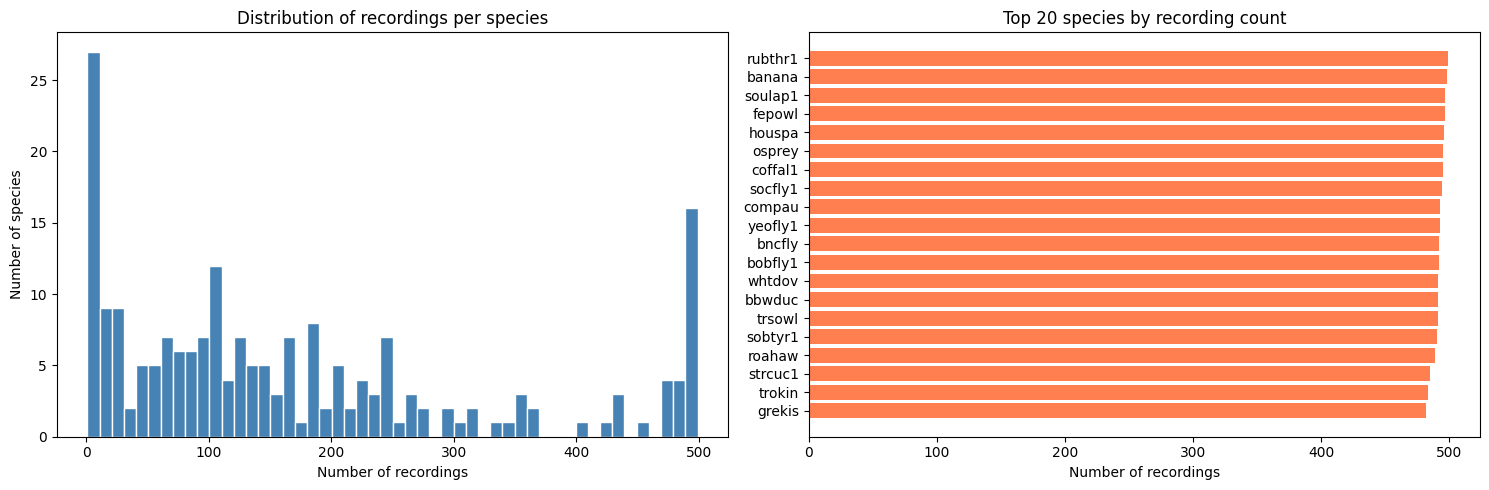

Species with < 5 recordings:  14
Species with < 10 recordings: 25
Most common species:  rubthr1 (499 recordings)
Rarest species:       516975 (1 recordings)


In [29]:
# ── Class imbalance ───────────────────────────────────────────────────────
species_counts = train_df[LABEL_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(species_counts.values, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of recordings per species')
axes[0].set_xlabel('Number of recordings')
axes[0].set_ylabel('Number of species')

top20 = species_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='coral')
axes[1].set_title('Top 20 species by recording count')
axes[1].set_xlabel('Number of recordings')

plt.tight_layout()
plt.show()

print(f'Species with < 5 recordings:  {(species_counts < 5).sum()}')
print(f'Species with < 10 recordings: {(species_counts < 10).sum()}')
print(f'Most common species:  {species_counts.idxmax()} ({species_counts.max()} recordings)')
print(f'Rarest species:       {species_counts.idxmin()} ({species_counts.min()} recordings)')

---
## CELL 3 — Visualize Sample Audio

Before building features, let's look at what a recording and its mel spectrogram actually look like.

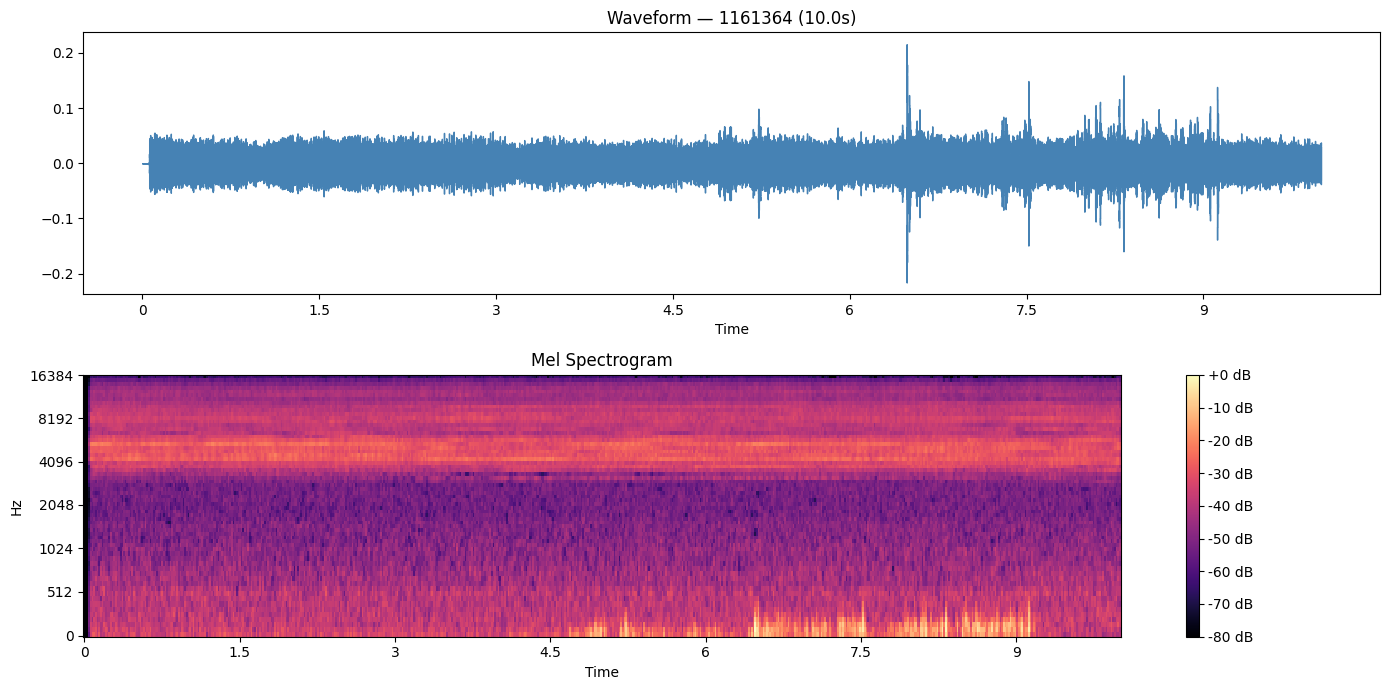

In [30]:
# ── Pick a sample file and visualize ──────────────────────────────────────
sample_row = train_df.iloc[0]
sample_path = cfg.TRAIN_AUDIO / sample_row[FILE_COL]

if sample_path.exists():
    y, sr = librosa.load(str(sample_path), sr=cfg.SR, duration=10)
    duration = librosa.get_duration(y=y, sr=sr)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Waveform — {sample_row[LABEL_COL]} ({duration:.1f}s)')

    # Mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH,
        n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(
        mel_db, sr=sr, hop_length=cfg.HOP_LENGTH,
        x_axis='time', y_axis='mel',
        fmin=cfg.FMIN, fmax=cfg.FMAX,
        ax=axes[1], cmap='magma'
    )
    axes[1].set_title('Mel Spectrogram')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()
else:
    print(f'File not found: {sample_path}')
    print(f'Contents of DATA_DIR: {sorted(os.listdir(cfg.DATA_DIR))}')

---
## CELL 4 — Build Feature Matrix (Mel Spectrograms)

For each training clip we:
1. Load the first `CLIP_SECONDS` of audio
2. Compute a mel spectrogram
3. Resize to a fixed `(N_MELS, N_FRAMES, 1)` tensor
4. Build a multi-hot label vector of shape `(num_species,)`

(Optional capping with MAX_SAMPLES (for now turned off))

In [31]:
# ── Build species lookup ──────────────────────────────────────────────────
num_species = len(species_cols)
species_to_idx = {label: idx for idx, label in enumerate(species_cols)}

print(f'Target species: {num_species}')
print(f'Species in train.csv that are also in submission: '
      f'{train_df[LABEL_COL].isin(species_to_idx).sum()} / {len(train_df)}')

Target species: 234
Species in train.csv that are also in submission: 35549 / 35549


In [32]:
def load_clip_mel(audio_path, cfg):
    """
    Load one audio file, take the first CLIP_SECONDS,
    compute a mel spectrogram, resize to fixed shape.
    Returns: np.ndarray of shape (N_MELS, N_FRAMES, 1), dtype float32
    """
    target_length = int(cfg.SR * cfg.CLIP_SECONDS)

    waveform, _ = librosa.load(
        str(audio_path), sr=cfg.SR, mono=True, duration=cfg.CLIP_SECONDS
    )

    # Pad or trim to exact length
    if len(waveform) < target_length:
        waveform = np.pad(waveform, (0, target_length - len(waveform)))
    else:
        waveform = waveform[:target_length]

    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=waveform, sr=cfg.SR,
        n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH,
        n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Resize to fixed width (N_FRAMES) using TF
    mel_resized = tf.image.resize(
        mel_db[..., np.newaxis],   # (N_MELS, time, 1)
        size=(cfg.N_MELS, cfg.N_FRAMES)
    ).numpy()

    return mel_resized.astype(np.float32)


print('load_clip_mel() defined.')

load_clip_mel() defined.


In [33]:
# ── Build X_train, y_train from a subset of training data ─────────────────
X_items = []
y_items = []
skipped = 0

for idx, row in train_df.iterrows():
    label = row[LABEL_COL]
    rel_path = row[FILE_COL]

    # Skip species not in submission columns
    if label not in species_to_idx:
        skipped += 1
        continue

    audio_path = cfg.TRAIN_AUDIO / str(rel_path)
    if not audio_path.exists():
        skipped += 1
        continue

    try:
        mel = load_clip_mel(audio_path, cfg)
    except Exception as e:
        skipped += 1
        continue

    # Multi-hot label
    y_vec = np.zeros(num_species, dtype=np.float32)
    y_vec[species_to_idx[label]] = 1.0

    X_items.append(mel)
    y_items.append(y_vec)

    # if len(X_items) >= cfg.MAX_SAMPLES:
    #     break

    if len(X_items) % 50 == 0:
        print(f'  Loaded {len(X_items)}')

X_train = np.stack(X_items, dtype=np.float32)
y_train = np.stack(y_items, dtype=np.float32)

print(f'\nDone.  X_train shape: {X_train.shape}   y_train shape: {y_train.shape}')
print(f'Skipped: {skipped}')

  Loaded 50
  Loaded 100
  Loaded 150
  Loaded 200
  Loaded 250
  Loaded 300
  Loaded 350
  Loaded 400
  Loaded 450
  Loaded 500
  Loaded 550
  Loaded 600
  Loaded 650
  Loaded 700
  Loaded 750
  Loaded 800
  Loaded 850
  Loaded 900
  Loaded 950
  Loaded 1000
  Loaded 1050
  Loaded 1100
  Loaded 1150
  Loaded 1200
  Loaded 1250
  Loaded 1300
  Loaded 1350
  Loaded 1400
  Loaded 1450
  Loaded 1500
  Loaded 1550
  Loaded 1600
  Loaded 1650
  Loaded 1700
  Loaded 1750
  Loaded 1800
  Loaded 1850
  Loaded 1900
  Loaded 1950
  Loaded 2000
  Loaded 2050
  Loaded 2100
  Loaded 2150
  Loaded 2200
  Loaded 2250
  Loaded 2300
  Loaded 2350
  Loaded 2400
  Loaded 2450
  Loaded 2500
  Loaded 2550
  Loaded 2600
  Loaded 2650
  Loaded 2700
  Loaded 2750
  Loaded 2800
  Loaded 2850
  Loaded 2900
  Loaded 2950
  Loaded 3000
  Loaded 3050
  Loaded 3100
  Loaded 3150
  Loaded 3200
  Loaded 3250
  Loaded 3300
  Loaded 3350
  Loaded 3400
  Loaded 3450
  Loaded 3500
  Loaded 3550
  Loaded 3600
  Loaded 365

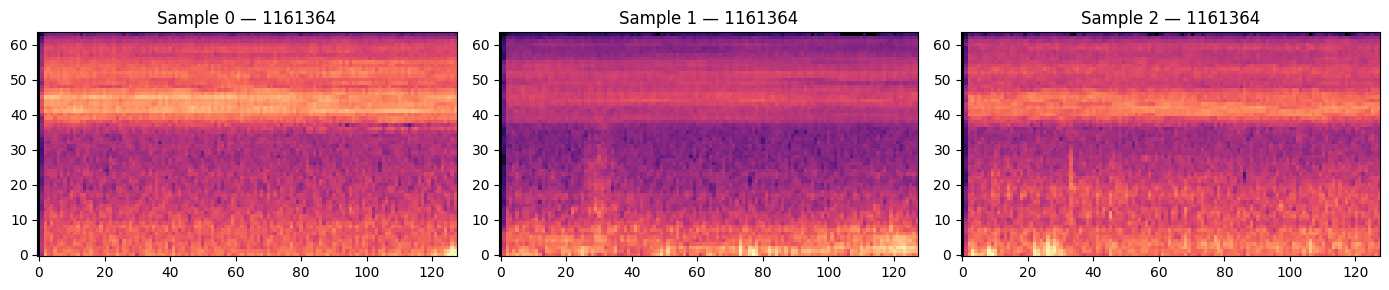

In [34]:
# ── Quick sanity check: show one spectrogram from the matrix ──────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i in range(min(3, len(X_train))):
    axes[i].imshow(X_train[i, :, :, 0], aspect='auto', origin='lower', cmap='magma')
    species_idx = np.argmax(y_train[i])
    axes[i].set_title(f'Sample {i} — {species_cols[species_idx]}')
plt.tight_layout()
plt.show()

---
## CELL 5 — Train/Validation Split

In [35]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=cfg.VAL_SPLIT,
    random_state=42
)

print(f'Train set:      {X_tr.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')

Train set:      30216 samples
Validation set: 5333 samples


---
## CELL 6 — Build a Simple CNN

Architecture (following the CNN lecture):

```
Input (N_MELS × N_FRAMES × 1)
  → Conv2D(16, 3×3, relu, same) → MaxPool(2×2)
  → Conv2D(32, 3×3, relu, same) → MaxPool(2×2)
  → Conv2D(64, 3×3, relu, same) → MaxPool(2×2)
  → GlobalAveragePooling2D
  → Dropout(0.3)
  → Dense(num_species, sigmoid)
```

- **Sigmoid + binary_crossentropy** because this is multi-label (a segment can have 0 or more species)
- GlobalAveragePooling instead of Flatten keeps the parameter count manageable

In [36]:
def build_cnn(input_shape, num_classes, dropout=0.3, lr=1e-3):
    """
    Simple 3-block CNN for mel spectrogram classification.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Block 1
        tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 2
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Block 3
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Classification head
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(num_classes, activation='sigmoid'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['binary_accuracy'],
    )
    return model


model = build_cnn(
    input_shape=X_tr.shape[1:],
    num_classes=num_species,
    dropout=cfg.DROPOUT,
    lr=cfg.LEARNING_RATE,
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 128, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 234)            │        15,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,506 (150.41 KB)

 Trainable params: 38,506 (150.41 KB)

 Non-trainable params: 0 (0.00 B)

---
## CELL 7 — Train the Model

In [37]:
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=cfg.EPOCHS,
    batch_size=cfg.BATCH_SIZE,
    verbose=1,
)

Epoch 1/5
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - binary_accuracy: 0.9729 - loss: 0.0843 - val_binary_accuracy: 0.9957 - val_loss: 0.0262
Epoch 2/5
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - binary_accuracy: 0.9957 - loss: 0.0267 - val_binary_accuracy: 0.9957 - val_loss: 0.0245
Epoch 3/5
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - binary_accuracy: 0.9957 - loss: 0.0252 - val_binary_accuracy: 0.9957 - val_loss: 0.0233
Epoch 4/5
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - binary_accuracy: 0.9957 - loss: 0.0240 - val_binary_accuracy: 0.9957 - val_loss: 0.0224
Epoch 5/5
1889/1889 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - binary_accuracy: 0.9957 - loss: 0.0232 - val_binary_accuracy: 0.9957 - val_loss: 0.0217


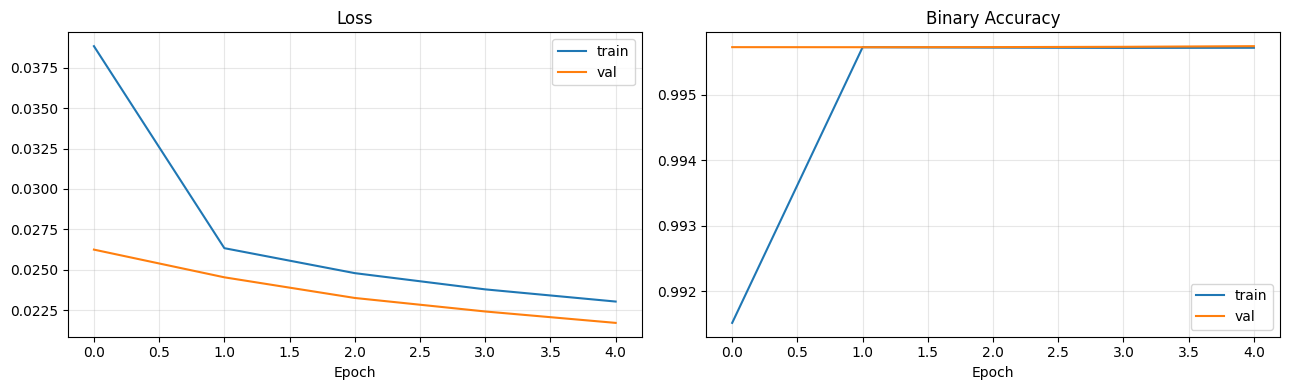

In [38]:
# ── Plot learning curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['binary_accuracy'], label='train')
axes[1].plot(history.history['val_binary_accuracy'], label='val')
axes[1].set_title('Binary Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Why does binary accuracy reach ~99.5% for both train and val?**

This is **misleading** — it does NOT mean the model is performing well. The reason is the extreme class imbalance in multi-label classification. With 234 species columns per sample, only 1 column is set to 1 (the primary label) and the other 233 are 0. A model that predicts 0 for every species on every sample would already score 233/234 = **99.57% binary accuracy**. So our model at 99.5% is essentially no better than predicting "no bird" for everything.

Binary accuracy counts each of the 234 columns as a separate prediction. Since ~99.6% of all values are 0, getting zeros right is trivial and completely dominates the metric. This is why the **ROC-AUC score** (0.83) is the meaningful metric — it measures ranking quality regardless of threshold and is what the Kaggle leaderboard actually uses.

**Takeaway:** ignore binary accuracy for this task. Use ROC-AUC and the per-species AUC distribution plot below to judge model quality.

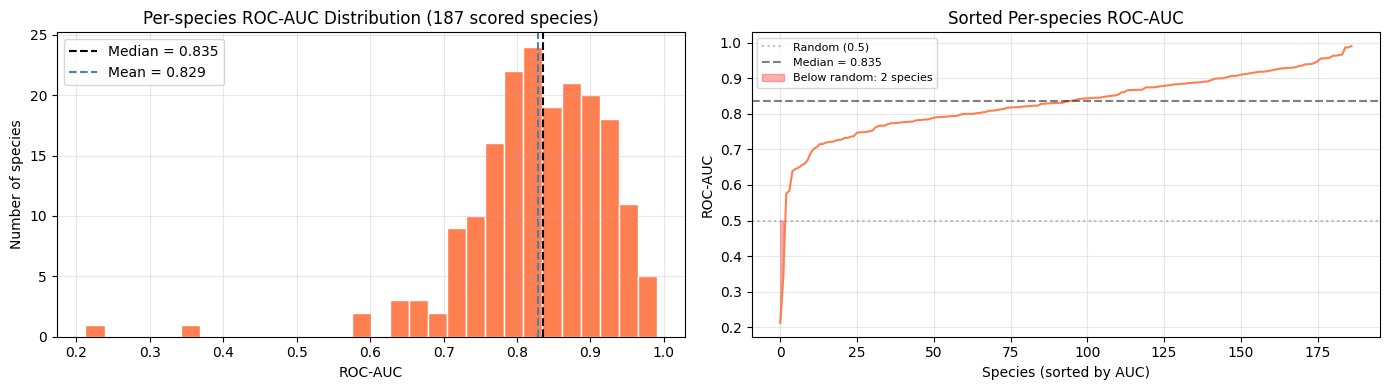

Scored species:     187
Mean ROC-AUC:       0.8287
Median ROC-AUC:     0.8349
Below 0.5 (random): 2 species
Above 0.9:          42 species

Bottom 5 species:
  74580: 0.2123
  1176823: 0.3432
  yebcar: 0.5767
  nacnig1: 0.5829
  epaori4: 0.6392

Top 5 species:
  ficman1: 0.9656
  22961: 0.9666
  24321: 0.9867
  yecmac: 0.9869
  738183: 0.9903


In [45]:
# ── Per-species ROC-AUC distribution (much more informative than binary accuracy) ──
y_pred_val = model.predict(X_val, verbose=0)

per_species_auc = {}
for i, col in enumerate(species_cols):
    if y_val[:, i].sum() > 0:
        per_species_auc[col] = roc_auc_score(y_val[:, i], y_pred_val[:, i])

auc_values = list(per_species_auc.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of per-species AUC
axes[0].hist(auc_values, bins=30, color='coral', edgecolor='white')
axes[0].axvline(np.median(auc_values), color='black', linestyle='--',
                label=f'Median = {np.median(auc_values):.3f}')
axes[0].axvline(np.mean(auc_values), color='steelblue', linestyle='--',
                label=f'Mean = {np.mean(auc_values):.3f}')
axes[0].set_title(f'Per-species ROC-AUC Distribution ({len(auc_values)} scored species)')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_ylabel('Number of species')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: sorted AUC curve — shows weakest and strongest species at a glance
sorted_aucs = sorted(auc_values)
axes[1].plot(range(len(sorted_aucs)), sorted_aucs, color='coral', linewidth=1.5)
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random (0.5)')
axes[1].axhline(np.median(auc_values), color='black', linestyle='--', alpha=0.5,
                label=f'Median = {np.median(auc_values):.3f}')
axes[1].fill_between(range(len(sorted_aucs)), sorted_aucs, 0.5,
                     where=[a < 0.5 for a in sorted_aucs], alpha=0.3, color='red',
                     label=f'Below random: {sum(a < 0.5 for a in sorted_aucs)} species')
axes[1].set_title('Sorted Per-species ROC-AUC')
axes[1].set_xlabel('Species (sorted by AUC)')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Quick stats ───────────────────────────────────────────────────────────
print(f'Scored species:     {len(auc_values)}')
print(f'Mean ROC-AUC:       {np.mean(auc_values):.4f}')
print(f'Median ROC-AUC:     {np.median(auc_values):.4f}')
print(f'Below 0.5 (random): {sum(a < 0.5 for a in auc_values)} species')
print(f'Above 0.9:          {sum(a > 0.9 for a in auc_values)} species')

# Worst 5 species
auc_series = pd.Series(per_species_auc).sort_values()
print(f'\nBottom 5 species:')
for name, val in auc_series.head(5).items():
    print(f'  {name}: {val:.4f}')
print(f'\nTop 5 species:')
for name, val in auc_series.tail(5).items():
    print(f'  {name}: {val:.4f}')

---
## CELL 8 — Quick Evaluation on Training Data

Compute macro ROC-AUC on the training set as a sanity check.  
With only 200 samples and 5 epochs this will be low — that's expected.

In [39]:
from sklearn.metrics import roc_auc_score

y_pred_val = model.predict(X_val, verbose=0)

# Only compute AUC for species that have at least one positive in val set
valid_cols = y_val.sum(axis=0) > 0
if valid_cols.sum() > 0:
    auc = roc_auc_score(
        y_val[:, valid_cols],
        y_pred_val[:, valid_cols],
        average='macro'
    )
    print(f'Validation macro ROC-AUC (over {valid_cols.sum()} species with positives): {auc:.4f}')
else:
    print('No species with positive labels in validation set.')

Validation macro ROC-AUC (over 187 species with positives): 0.8287


In [40]:
# ── Official BirdCLEF+ 2026 evaluation metric ────────────────────────────
# Reimplemented locally from the Kaggle scoring function.
# The official metric is: macro-averaged ROC-AUC, skipping any species
# column where the solution (ground truth) has zero positive labels.

def kaggle_birdclef_score(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame, row_id_column: str = 'row_id') -> dict:
    """
    Replicates the official Kaggle BirdCLEF+ 2026 scoring function.

    Args:
        y_true_df: DataFrame with row_id + one column per species (ground truth, 0/1)
        y_pred_df: DataFrame with row_id + one column per species (predicted probabilities)
        row_id_column: name of the ID column to drop before scoring

    Returns:
        dict with overall score and per-species breakdown
    """
    sol = y_true_df.drop(columns=[row_id_column], errors='ignore')
    sub = y_pred_df.drop(columns=[row_id_column], errors='ignore')

    # Validate: all prediction columns must be numeric
    non_numeric = {c: sub[c].dtype for c in sub.columns if not pd.api.types.is_numeric_dtype(sub[c])}
    if non_numeric:
        raise ValueError(f'Non-numeric columns in submission: {non_numeric}')

    # Find scored columns: only species with at least one positive in ground truth
    solution_sums = sol.sum(axis=0)
    scored_columns = list(solution_sums[solution_sums > 0].index)

    if len(scored_columns) == 0:
        return {
            'macro_roc_auc': float('nan'),
            'scored_species': 0,
            'skipped_species': len(sol.columns),
            'per_species_auc': {},
        }

    # Per-species AUC (mirrors sklearn macro averaging)
    per_species = {}
    for col in scored_columns:
        try:
            auc = roc_auc_score(sol[col].values, sub[col].values)
        except ValueError:
            # Only one class present in ground truth for this column
            auc = float('nan')
        per_species[col] = auc

    valid_aucs = [v for v in per_species.values() if not np.isnan(v)]
    macro_auc = float(np.mean(valid_aucs)) if valid_aucs else float('nan')

    return {
        'macro_roc_auc': macro_auc,
        'scored_species': len(scored_columns),
        'skipped_species': len(sol.columns) - len(scored_columns),
        'per_species_auc': per_species,
    }


# ── Run official metric on validation set ─────────────────────────────────
# Package y_val and y_pred_val into DataFrames that mirror submission format

val_true_df = pd.DataFrame(y_val, columns=species_cols)
val_true_df.insert(0, 'row_id', [f'val_{i}' for i in range(len(y_val))])

val_pred_df = pd.DataFrame(y_pred_val, columns=species_cols)
val_pred_df.insert(0, 'row_id', [f'val_{i}' for i in range(len(y_pred_val))])

result = kaggle_birdclef_score(val_true_df, val_pred_df, row_id_column='row_id')

print(f'=== Official Kaggle BirdCLEF Metric ===')
print(f'Macro ROC-AUC:    {result["macro_roc_auc"]:.4f}')
print(f'Scored species:   {result["scored_species"]}')
print(f'Skipped species:  {result["skipped_species"]} (no positives in val set)')

# Show per-species breakdown for the scored species
if result['per_species_auc']:
    auc_series = pd.Series(result['per_species_auc']).sort_values()
    print(f'\nLowest  AUC species: {auc_series.index[0]}  ({auc_series.iloc[0]:.4f})')
    print(f'Highest AUC species: {auc_series.index[-1]} ({auc_series.iloc[-1]:.4f})')
    print(f'Median  AUC:         {auc_series.median():.4f}')

=== Official Kaggle BirdCLEF Metric ===
Macro ROC-AUC:    0.8287
Scored species:   187
Skipped species:  47 (no positives in val set)

Lowest  AUC species: 74580  (0.2123)
Highest AUC species: 738183 (0.9903)
Median  AUC:         0.8349


### How the two evaluation metrics differ

**Our quick sklearn check (Cell 8):**
- Operates directly on numpy arrays `y_val` and `y_pred_val`
- Filters columns with `y_val.sum(axis=0) > 0` (same idea)
- Calls `roc_auc_score(..., average='macro')` in one shot
- Returns a single number — no visibility into which species are easy vs. hard

**The official Kaggle metric (Cell above):**
- Operates on **DataFrames** with a `row_id` column, exactly mirroring the submission format — this makes it a direct sanity check that your submission pipeline produces valid output
- Validates that all prediction columns are numeric (catches a common submission bug where species columns accidentally contain strings)
- Computes **per-species AUC individually**, then averages — this means we can inspect which species the model struggles with and which it gets right, which is critical for guiding the agent's next iteration
- Skips species with zero positives in ground truth, which is the same logic but explicitly matches the Kaggle leaderboard calculation
- Reports `scored_species` vs `skipped_species` counts — with only 200 training samples most of the 234 species have no representation, so knowing how many are actually being evaluated helps interpret the score

**In practice the two numbers should be identical** (or very close) when run on the same data. The real value of the official version is: (1) it validates submission format, (2) it gives per-species diagnostics, and (3) it's the exact same logic Kaggle uses, so there are no surprises on the leaderboard.

---
## CELL 9 — Generate Submission CSV

For a real Kaggle submission we'd run inference on `test_soundscapes/`.  
Since those are hidden at training time, we create a **valid submission file**  
using the training-set predictions as a placeholder.  

The format matches `sample_submission.csv` exactly:  
`row_id, species_1, species_2, ..., species_234`

In [41]:
# ── Build submission ──────────────────────────────────────────────────────
# If test soundscapes exist, process them; otherwise create a dummy submission
# that matches the sample_submission format.

test_soundscape_dir = cfg.TEST_SOUNDSCAPES
test_files = sorted(test_soundscape_dir.glob('*.ogg')) if test_soundscape_dir.exists() else []

if test_files:
    print(f'Found {len(test_files)} test soundscapes — running inference...')
    all_rows = []

    for fpath in test_files:
        soundscape_name = fpath.stem
        y_full, _ = librosa.load(str(fpath), sr=cfg.SR, mono=True)
        total_secs = int(len(y_full) / cfg.SR)
        segment_samples = cfg.SR * cfg.CLIP_SECONDS

        for start in range(0, len(y_full), segment_samples):
            end = start + segment_samples
            segment = y_full[start:end]
            if len(segment) < segment_samples:
                segment = np.pad(segment, (0, segment_samples - len(segment)))

            end_sec = (start // segment_samples + 1) * cfg.CLIP_SECONDS
            row_id = f'{soundscape_name}_{end_sec}'

            # Compute mel and predict
            mel = librosa.feature.melspectrogram(
                y=segment, sr=cfg.SR,
                n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH,
                n_mels=cfg.N_MELS, fmin=cfg.FMIN, fmax=cfg.FMAX, power=2.0,
            )
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_resized = tf.image.resize(
                mel_db[..., np.newaxis], size=(cfg.N_MELS, cfg.N_FRAMES)
            ).numpy().astype(np.float32)

            preds = model.predict(mel_resized[np.newaxis, ...], verbose=0)[0]

            row = {'row_id': row_id}
            for col, prob in zip(species_cols, preds):
                row[col] = float(prob)
            all_rows.append(row)

    submission_df = pd.DataFrame(all_rows)

else:
    print('No test soundscapes found (expected during training).')
    print('Creating a placeholder submission matching sample_submission format...')

    # Use mean training predictions as a simple placeholder
    y_pred_all = model.predict(X_train, verbose=0)
    mean_preds = y_pred_all.mean(axis=0)

    submission_df = sample_sub.copy()
    for idx, col in enumerate(species_cols):
        submission_df[col] = float(mean_preds[idx])


# ── Ensure correct column order ────────────────────────────────────────────
submission_df = sample_sub[['row_id']].merge(submission_df, on='row_id', how='left')
submission_df[species_cols] = submission_df[species_cols].fillna(0.0).clip(0.0, 1.0)

print(f'\nSubmission shape: {submission_df.shape}  (expected: {sample_sub.shape})')
print(f'Columns match:    {list(submission_df.columns) == list(sample_sub.columns)}')
print(f'NaN count:        {submission_df.isnull().sum().sum()}')
submission_df.head()

No test soundscapes found (expected during training).
Creating a placeholder submission matching sample_submission format...

Submission shape: (3, 235)  (expected: (3, 235))
Columns match:    True
NaN count:        0


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.000198,0.00001,0.000238,4.454489e-07,0.000034,0.000011,0.000141,0.000165,0.000124,...,0.0017,0.011317,0.001469,0.001672,0.000621,0.007152,0.000671,0.004004,0.001014,0.011603
1,BC2026_Test_0001_S05_20250227_010002_10,0.000198,0.00001,0.000238,4.454489e-07,0.000034,0.000011,0.000141,0.000165,0.000124,...,0.0017,0.011317,0.001469,0.001672,0.000621,0.007152,0.000671,0.004004,0.001014,0.011603
2,BC2026_Test_0001_S05_20250227_010002_15,0.000198,0.00001,0.000238,4.454489e-07,0.000034,0.000011,0.000141,0.000165,0.000124,...,0.0017,0.011317,0.001469,0.001672,0.000621,0.007152,0.000671,0.004004,0.001014,0.011603


In [42]:
# ── Save ───────────────────────────────────────────────────────────────────
submission_path = cfg.SUBMISSION_DIR / 'submission_first_cnn.csv'
submission_df.to_csv(submission_path, index=False)

# Verify
assert submission_path.exists(), 'Submission file was not saved!'
verify = pd.read_csv(submission_path)
print(f'Saved to: {submission_path}')
print(f'Verified shape: {verify.shape}')
print(f'File size: {submission_path.stat().st_size / 1024:.1f} KB')

Saved to: /Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/APA-Project/submission/submission_first_cnn.csv
Verified shape: (3, 235)
File size: 16.8 KB


---
## Summary & Next Steps

**What we built:**
- A complete pipeline: audio → mel spectrogram → CNN → submission CSV
- Simple 3-block Conv2D architecture (Conv → ReLU → MaxPool pattern from the lecture)
- Multi-label classification with sigmoid + binary_crossentropy

**This is intentionally minimal to understand what our agent needs to build and give him clear guidelines.** 
